using: cpu
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
dataset saved at: /kaggle/input/chest-xray-pneumonia
train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
val:   /kaggle/input/chest-xray-pneumonia/chest_xray/val
test:  /kaggle/input/chest-xray-pneumonia/chest_xray/test
classes: ['NORMAL', 'PNEUMONIA']
train size: 5216
test size: 624


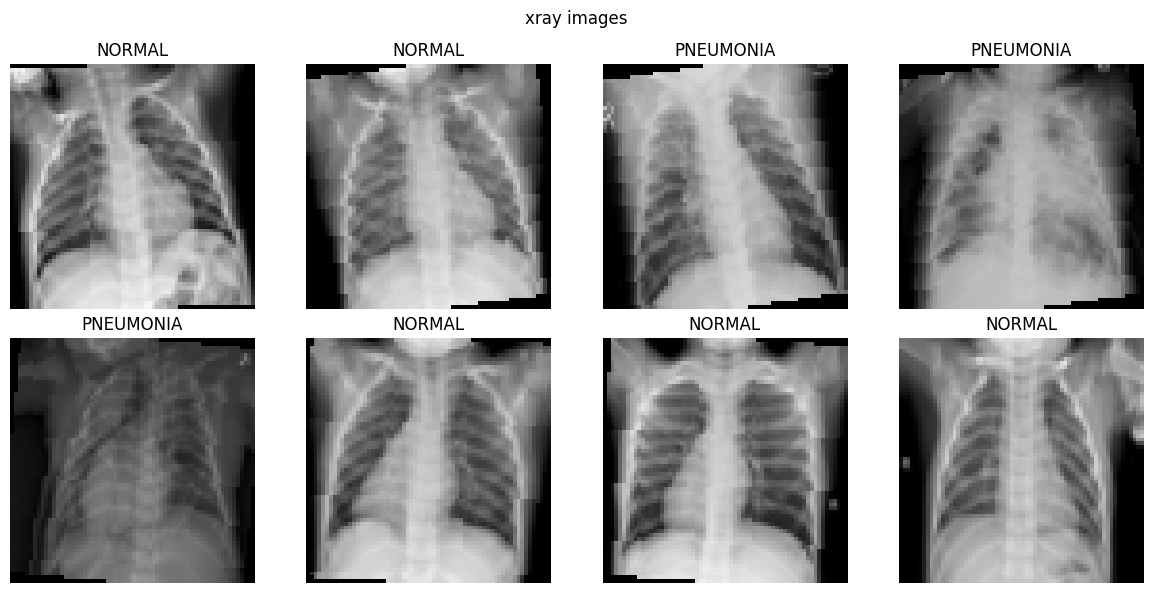

total parameters: 548258
model built successfully
ready to train for 10 epochs
starting training

epoch 1/10  loss: 0.415  acc: 80.3%  val_acc: 75.0%
epoch 2/10  loss: 0.205  acc: 91.8%  val_acc: 75.0%
epoch 3/10  loss: 0.165  acc: 94.0%  val_acc: 68.8%
epoch 4/10  loss: 0.140  acc: 94.6%  val_acc: 81.2%
epoch 5/10  loss: 0.131  acc: 95.0%  val_acc: 62.5%
epoch 6/10  loss: 0.127  acc: 95.4%  val_acc: 87.5%
epoch 7/10  loss: 0.118  acc: 95.5%  val_acc: 81.2%
epoch 8/10  loss: 0.110  acc: 96.0%  val_acc: 68.8%
epoch 9/10  loss: 0.099  acc: 96.4%  val_acc: 75.0%
epoch 10/10  loss: 0.098  acc: 96.7%  val_acc: 75.0%

Complete
best val accuracy: 87.5 %
model saved


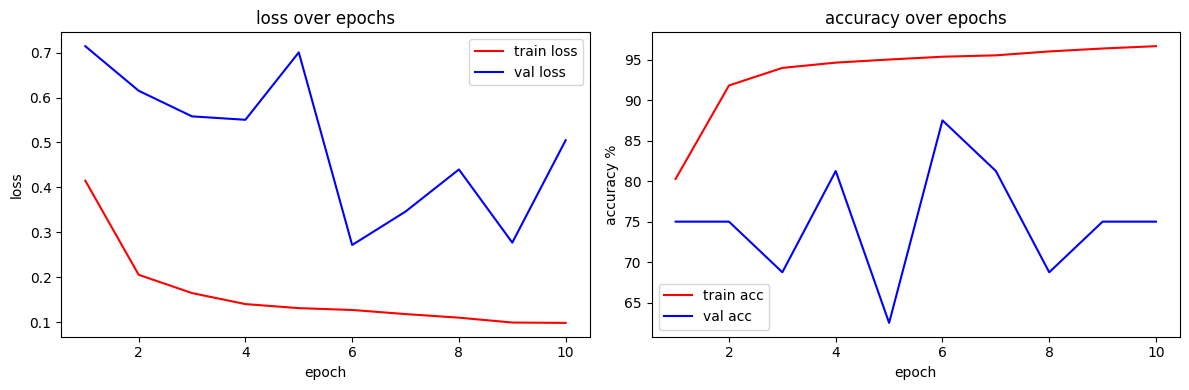

graph saved
test accuracy: 75.2 %

              precision    recall  f1-score   support

      NORMAL       0.92      0.37      0.53       234
   PNEUMONIA       0.72      0.98      0.83       390

    accuracy                           0.75       624
   macro avg       0.82      0.68      0.68       624
weighted avg       0.79      0.75      0.72       624



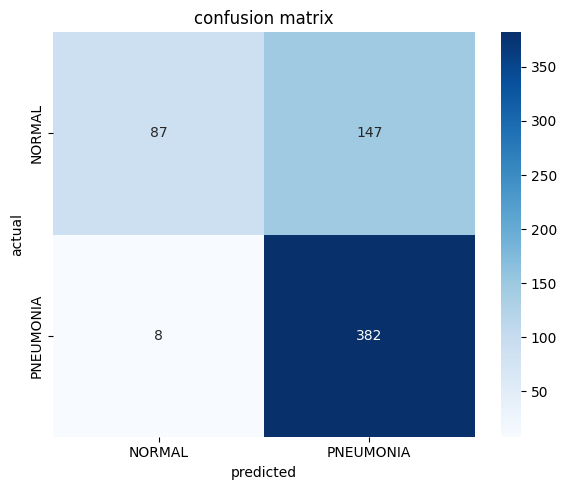

true label: PNEUMONIA


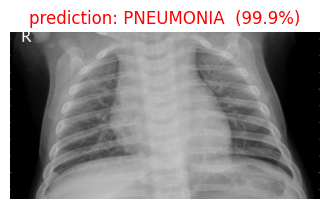

normal:     0.1 %
pneumonia:  99.9 %


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded!


In [2]:
!pip install kagglehub

# Library

import os
import torch
import torch.nn as nn
import kagglehub
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import copy
import random

# check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using:", device)



# Dataset

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("dataset saved at:", path )

train_folder = os.path.join(path, "chest_xray", "train")
val_folder   = os.path.join(path, "chest_xray", "val")
test_folder  = os.path.join(path, "chest_xray", "test")

print("train:", train_folder)
print("val:  ", val_folder)
print("test: ", test_folder)


# prepare images
# add random flips and rotations
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

#resize
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_folder, transform=train_transform)
val_data   = datasets.ImageFolder(val_folder,   transform=test_transform)
test_data  = datasets.ImageFolder(test_folder,  transform=test_transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

class_names = train_data.classes
print("classes:", class_names)
print("train size:", len(train_data))
print("test size:", len(test_data))



# Show Images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flat:
    idx = random.randint(0, len(train_data) - 1)
    image, label = train_data[idx]
    image = image.numpy().transpose(1, 2, 0)
    image = np.clip(image, 0, 1)
    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")
plt.suptitle("xray images")
plt.tight_layout()
plt.show()


# Building CNN
class MyCNN(nn.Module):

    def __init__(self):
        super(MyCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
model = MyCNN()
model = model.to(device)

# count parameters
total = sum(p.numel() for p in model.parameters())
print("total parameters:", total)
print("model built successfully")



# Training
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
NUM_EPOCHS = 10
print("ready to train for", NUM_EPOCHS, "epochs")
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_accuracy    = 0
best_weights     = None

print("starting training\n")

for epoch in range(NUM_EPOCHS):

    model.train()
    running_loss = 0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predicted     = outputs.argmax(dim=1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    model.eval()
    v_loss    = 0
    v_correct = 0
    v_total   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs   = model(images)
            loss      = loss_function(outputs, labels)
            v_loss   += loss.item()
            predicted  = outputs.argmax(dim=1)
            v_correct += (predicted == labels).sum().item()
            v_total   += labels.size(0)
    val_loss = v_loss / len(val_loader)
    val_acc  = v_correct / v_total
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_weights  = copy.deepcopy(model.state_dict())
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"epoch {epoch+1}/{NUM_EPOCHS}  loss: {train_loss:.3f}  acc: {train_acc*100:.1f}%  val_acc: {val_acc*100:.1f}%")
print("\nComplete")
print("best val accuracy:", round(best_accuracy * 100, 1), "%")

model.load_state_dict(best_weights)


# Save and downloding

torch.save(model.state_dict(), "my_model.pth")
print("model saved")
# plot the training graphs
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, train_losses, label="train loss", color="red")
ax1.plot(epochs, val_losses,   label="val loss",   color="blue")
ax1.set_title("loss over epochs")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.legend()
ax2.plot(epochs, [a*100 for a in train_accs], label="train acc", color="red")
ax2.plot(epochs, [a*100 for a in val_accs],   label="val acc",   color="blue")
ax2.set_title("accuracy over epochs")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy %")
ax2.legend()
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()
print("graph saved")

# testing

model.eval()
all_preds  = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs   = model(images)
        predicted = outputs.argmax(dim=1)
        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(labels.tolist())

# accuracy
correct  = sum(p == l for p, l in zip(all_preds, all_labels))
accuracy = correct / len(all_labels) * 100

print("test accuracy:", round(accuracy, 1), "%")
print()
print(classification_report(all_labels, all_preds, target_names=class_names))


# onfusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


# test on single image


def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1)[0]

    pred       = probs.argmax().item()
    pred_name  = class_names[pred]
    confidence = probs[pred].item() * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"prediction: {pred_name}  ({confidence:.1f}%)",
              color="red" if pred_name == "PNEUMONIA" else "green")
    plt.show()

    print("normal:    ", round(probs[0].item() * 100, 1), "%")
    print("pneumonia: ", round(probs[1].item() * 100, 1), "%")


#random test image and predict
img_path, true_label = random.choice(test_data.samples)
print("true label:", class_names[true_label])
predict_image(img_path)


# Download

import shutil
from google.colab import files

os.makedirs("results", exist_ok=True)
shutil.copy("training_curves.png",  "results/")
shutil.copy("confusion_matrix.png", "results/")
shutil.copy("my_model.pth",         "results/")

shutil.make_archive("results", "zip", "results")
files.download("results.zip")
print("downloaded!")